> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib pandas tabulate


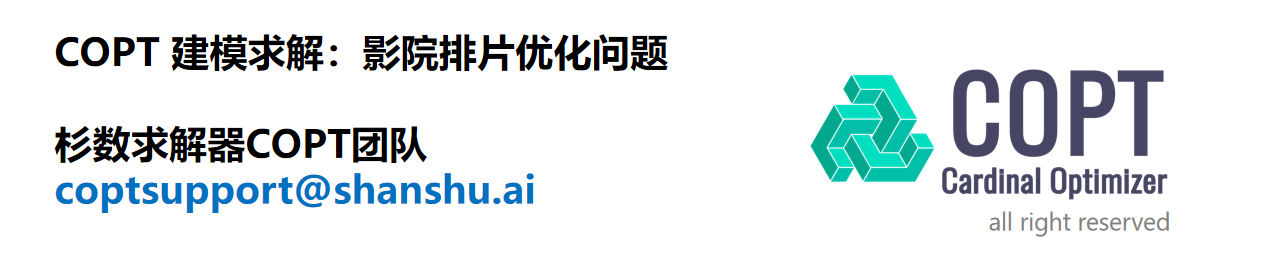

# 影院排片优化问题代码实现
## 使用COPT建模求解影院排片优化问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **添加数据模型**
   - 导入影片数据（时长、评分、题材、语言、允许版本、分成比例等）
   - 导入影院放映厅数据（容量、支持版本、播放成本等）
   - 添加其他参数数据（放映厅基础单位成本、固定成本、排片最小间隔、黄金时段涨价系数等）

3. **数据预处理**
   - 放映厅数据和影片数据预处理
   - 构建辅助集合（如 `allowed_versions`、`room_supports`、`genre_to_movies`、`valid_start_time` 等）

4. **创建COPT求解环境与模型**

5. **构建模型：依次添加三要素**
   - **决策变量**：定义排片变量 $x_{r,m,v,t}$ ，表示影片 $m$ 在放映厅 $r$ 于时间 $t$ 播放版本 $v$ 是否被排入，通过变量预筛选减小问题规模；
   - **目标函数**：根据要求计算收入和成本，最大化一个营业周期内影院的净收益；
   - **约束条件**：
     - 时间不冲突约束（包含清理维护间隔要求）；
     - 时间窗累计播放时长约束；
     - 题材播放次数约束；
     - 版本播放总时长约束。

6. **求解**

7. 查看、分析**结果**：输出排片计划表、逐条**校验约束**、绘制**排片甘特图**与收益曲线

## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT

from collections import defaultdict
import math
import pandas as pd
from tabulate import tabulate

## 添加模型数据

In [6]:
movie_data = [{'id': '436270', 'genres': 'Action,Fantasy,Science Fiction', 'original_language': 'English', 'version': '2D', 'runtime': '125', 'rating': '6.092', 'basic_price': '41'},
              {'id': '882598', 'genres': 'Horror,Mystery,Thriller', 'original_language': 'English', 'version': '2D', 'runtime': '116', 'rating': '6.715', 'basic_price': '43'},
              {'id': '505642', 'genres': 'Action,Adventure,Science Fiction', 'original_language': 'English', 'version': '2D', 'runtime': '161', 'rating': '6.473', 'basic_price': '45'},
              {'id': '966220', 'genres': 'Drama,Action,War', 'original_language': 'Ukrainian', 'version': '2D', 'runtime': '120', 'rating': '7.393', 'basic_price': '46'},
              {'id': '663712', 'genres': 'Horror,Thriller', 'original_language': 'English', 'version': '2D', 'runtime': '138', 'rating': '6.461', 'basic_price': '44'},
              {'id': '829280', 'genres': 'Mystery,Adventure,Crime', 'original_language': 'English', 'version': '2D', 'runtime': '129', 'rating': '7.373', 'basic_price': '42'},
              {'id': '676701', 'genres': 'Adventure,Animation,Comedy', 'original_language': 'Spanish', 'version': '2D', 'runtime': '89', 'rating': '7.375', 'basic_price': '48'},
              {'id': '675054', 'genres': 'Horror,Action,Comedy', 'original_language': 'Spanish', 'version': '2D', 'runtime': '93', 'rating': '6.333', 'basic_price': '43'},
              {'id': '979924', 'genres': 'Thriller', 'original_language': 'English', 'version': '2D', 'runtime': '104', 'rating': '6.066', 'basic_price': '42'},
              {'id': '235672', 'genres': 'Adventure,Action,Science Fiction', 'original_language': 'English', 'version': '2D', 'runtime': '134', 'rating': '5.908', 'basic_price': '41'},
              {'id': '672392', 'genres': 'Action,Adventure,Adventure,Thriller', 'original_language': 'English', 'version': '2D', 'runtime': '170', 'rating': '6.872', 'basic_price': '42'},
              {'id': '721193', 'genres': 'Action,Drama', 'original_language': 'English', 'version': '2D,3D,IMAX', 'runtime': '156', 'rating': '7.864', 'basic_price': '48'},
              {'id': '812924', 'genres': 'Animation,Fantasy,Adventure,Action', 'original_language': 'Mandarin', 'version': '2D,3D,IMAX', 'runtime': '144', 'rating': '8.25', 'basic_price': '45'},
              {'id': '192801', 'genres': 'Family,Comedy,Adventure,Animation,Science Fiction', 'original_language': 'English', 'version': '2D', 'runtime': '98', 'rating': '6.941', 'basic_price': '43'},
              {'id': '723921', 'genres': 'Comedy,Suspense,Action', 'original_language': 'Mandarin,English', 'version': '2D', 'runtime': '136', 'rating': '5.5', 'basic_price': '46'},
              {'id': '402101', 'genres': 'Family,Comedy,Adventure,Science Fiction', 'original_language': 'English', 'version': '2D', 'runtime': '104', 'rating': '7.1', 'basic_price': '40'},
              {'id': '837808', 'genres': 'Fantasy,Family,Action', 'original_language': 'English', 'version': '2D', 'runtime': '126', 'rating': '7.9', 'basic_price': '46'},
              {'id': '180219', 'genres': 'Drama,Crime', 'original_language': 'Mandarin,Shanghainese', 'version': '2D', 'runtime': '96', 'rating': '7.737', 'basic_price': '40'},
              {'id': '290003', 'genres': 'Action,Adventure,Drama', 'original_language': 'English,Mandarin', 'version': '2D', 'runtime': '94', 'rating': '7.207', 'basic_price': '47'}]

cinema_data = [{'room': 'R01', 'capacity': '130', '2D': '1', '3D': '1', 'IMAX': '0'},
               {'room': 'R02', 'capacity': '90', '2D': '1', '3D': '1', 'IMAX': '1'},
               {'room': 'R03', 'capacity': '100', '2D': '1', '3D': '0', 'IMAX': '0'},
               {'room': 'R04', 'capacity': '150', '2D': '1', '3D': '1', 'IMAX': '1'},
               {'room': 'R05', 'capacity': '100', '2D': '1', '3D': '0', 'IMAX': '0'},
               {'room': 'R06', 'capacity': '100', '2D': '1', '3D': '1', 'IMAX': '0'},
               {'room': 'R07', 'capacity': '120', '2D': '1', '3D': '1', 'IMAX': '1'},
               {'room': 'R08', 'capacity': '100', '2D': '1', '3D': '1', 'IMAX': '0'}]

basic_cost = 2.42
fixed_cost = 90
min_gap = 15
prime_coeff = 1.30
genre_bounds = {
    "Animation":(1, 5),
    "Horror": (0, 3),
    "Action": (2, 6),
    "Drama": (1, 6),
}
max_runtime = {"3D": 1200, "IMAX": 1500}

## 数据预处理

预处理只**读取** `movie_data` / `cinema_data`，并把结果写进新的字典，不在原始数据上做原地修改。
这样任意一个 cell 被重复执行都不会把已经处理过的数据再处理一遍（例如把已取整的时长再取整一次）。

In [8]:
# ---------- 版本系数 ----------
VERSION_PRICE_COEFF = {"2D": 1.00, "3D": 1.20, "IMAX": 1.23}   # 票价系数
VERSION_COST_COEFF = {"2D": 1.00, "3D": 1.10, "IMAX": 1.15}    # 成本系数

# ---------- 时间轴 ----------
OPEN_MIN, CLOSE_MIN, STEP = 0, 1020, 15   # 0 = 10:00，1020 = 次日 03:00，步长 15 min


def round_runtime(minutes, unit=30):
    """把播放时长向上取整到 unit 分钟的倍数：125 -> 150，而 120 仍为 120。"""
    return math.ceil(minutes / unit) * unit


# ---------- 放映厅数据处理 ----------
capacity = {r["room"]: int(r["capacity"]) for r in cinema_data}
# 每个放映厅支持的版本
room_supports = {r["room"]: [v for v in ("2D", "3D", "IMAX") if int(r[v])]
                 for r in cinema_data}
# 播放成本 cost = version_coeff * capacity * basic_cost + fixed_cost
cost = {room: {v: VERSION_COST_COEFF[v] * capacity[room] * basic_cost + fixed_cost
               for v in supported}
        for room, supported in room_supports.items()}

# ---------- 影片数据处理 ----------
genres = {m["id"]: m["genres"].split(",") for m in movie_data}
languages = {m["id"]: m["original_language"].split(",") for m in movie_data}
allowed_versions = {m["id"]: m["version"].split(",") for m in movie_data}
runtime = {m["id"]: round_runtime(int(m["runtime"])) for m in movie_data}
rating = {m["id"]: float(m["rating"]) for m in movie_data}
basic_price = {m["id"]: int(m["basic_price"]) for m in movie_data}
# 票价：3D 为 2D 的 1.2 倍，IMAX 为 2D 的 1.23 倍
price = {mid: {v: VERSION_PRICE_COEFF[v] * basic_price[mid] for v in vs}
         for mid, vs in allowed_versions.items()}
# 分成系数：原始语言含普通话视为国产片
sharing_rate = {mid: 0.43 if "Mandarin" in langs else 0.51
                for mid, langs in languages.items()}

## 生成集合和映射

In [10]:
# ---------- 基础集合 ----------
rooms = [r["room"] for r in cinema_data]
movies = [m["id"] for m in movie_data]
versions = ["2D", "3D", "IMAX"]

# 黄金时段 18:00-21:00，约定闭区间：18:00 与 21:00 开场的场次都按 1.3 倍票价计
prime_time = list(range(480, 660 + 1, STEP))

# ---------- 映射集合 ----------
genre_to_movies = defaultdict(list)
for mid in movies:
    for g in genres[mid]:
        genre_to_movies[g].append(mid)

version_to_movies = defaultdict(list)
for mid in movies:
    for v in allowed_versions[mid]:
        version_to_movies[v].append(mid)

# 上座人数 = floor(放映厅容量 * 评分 / 10)
attendance = {r: {m: math.floor(capacity[r] * rating[m] / 10) for m in movies}
              for r in rooms}


# ---------- 合法开播时间 ----------
def get_valid_time(movie_genres, movie_runtime,
                   open_time=OPEN_MIN, close_time=CLOSE_MIN, step=STEP):
    """
    根据影片题材和时长，返回合法的开播时间集合
    - movie_genres : list[str] 影片题材
    - movie_runtime: int 影片播放时长（已按 30 分钟取整）
    - open_time    : int 营业开始时间（默认 0，即 10:00）
    - close_time   : int 营业结束时间（默认 1020，即次日 03:00）
    - step         : int 时间步长（默认 15 分钟）
    """
    # 默认：营业时间内、且能在打烊前放完
    earliest, latest = open_time, close_time - movie_runtime

    # 动画 / 家庭：限制在白天（最晚 19:00 开场）
    if any(g in movie_genres for g in ["Animation", "Family"]):
        latest = min(latest, 540)

    # 恐怖 / 惊悚：限制在晚上（最早 21:00 开场）
    if any(g in movie_genres for g in ["Horror", "Thriller"]):
        earliest = max(earliest, 660)

    if latest < earliest:
        return []
    return list(range(earliest, latest + 1, step))


valid_start_time = {mid: get_valid_time(genres[mid], runtime[mid]) for mid in movies}

## 创建求解环境和求解模型

In [12]:
env = cp.Envr()
model = env.createModel("Movie_Schedule")

Cardinal Optimizer v8.0.6. Build date Aug  7 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量
$$
x_{r,m,v,t} =
\begin{cases}
1,\ \text{代表在放映厅 $r$ 时间 $t$ 开始播放电影 $m$ 的 $v$ 版本} \\
0,\ \text{否则}
\end{cases}
$$
- 一部电影允许的播放时间不能超过营业时间、需要满足题材限制，可以通过 $valid\_start\_time$ 映射进行有效的播放时间遍历；
- 房间支持版本需要和影片播放版本匹配，可以只遍历同时存在于 $allowed\_versions$ 和 $room\_supports$ 的版本。

这些约束可以在变量预筛选阶段实现，无须在模型中构造。

In [14]:
x = {}
for r in rooms:
    for m in movies:
        for v in set(allowed_versions[m]) & set(room_supports[r]):
            for t in valid_start_time[m]:
                x[r, m, v, t] = model.addVar(vtype=COPT.BINARY, name=f"x({r},{m},{v},{t})")

print(f"预筛选后共生成 {len(x)} 个决策变量")

预筛选后共生成 7222 个决策变量


### 设置目标函数
最大化一个营业周期内的净收益：
$$
\text{影院一个营业周期内净收益} = \sum_{\text{所有场次}} \big[ \text{售票收入} \times (1 - \text{制片方分成比例}) - \text{播放成本} \big]
$$
$$
\max_{x_{r,m,v,t}}
\sum_{r} \sum_{m} \sum_{v} \sum_{t}
x_{r,m,v,t} \cdot \Big( \big(attendance[r][m] \cdot price[m][v] \cdot prime\_coeff \big) \cdot (1 - sharing\_rate[m]) - cost[r][v] \Big)
$$

In [16]:
model.setObjective(
    cp.quicksum(
        x[r, m, v, t] * (
            attendance[r][m] * price[m][v] * (prime_coeff if t in prime_time else 1.0) * (1-sharing_rate[m]) - cost[r][v]
        )
        for (r, m, v, t) in x
    ),
    sense=COPT.MAXIMIZE
)

### 添加约束条件

1. **时间不冲突约束（包含清理维护间隔要求）**

   每个放映厅在同一时刻只能播放一部影片，且相邻两场之间需预留 $min\_gap$ 分钟清场。

   一种直接的写法是对**每一对**冲突变量写一条 $x_1 + x_2 \le 1$，但这样约束数量是变量数的平方量级
   （本例约 108 万条），既构造缓慢，线性松弛也很弱。

   换一个角度来看：把清场时间并入占用时间，则一个场次对放映厅的占用就是一段区间
   $[t,\ t + runtime[m] + min\_gap)$，而“两场互不冲突”等价于
   “任一时刻最多只有一场占用该放映厅”。于是可以按**时刻**逐个写约束：

$$
\forall r \in rooms,\ \forall \tau \in \{0, 15, \ldots, 1020\}:
$$
$$
\sum_{m}\sum_{v}\sum_{\substack{t \in valid\_start\_time[m] \\ t \le \tau < t + runtime[m] + min\_gap}}
x_{r,m,v,t} \leq 1
$$

   由于所有开播时间、影片时长、清场间隔都是 15 分钟的倍数，只需在 15 分钟的网格上枚举 $\tau$ 即可，
   两种写法对 0-1 变量而言**可行域完全相同**。约束数量从约 108 万条降到
   $8 \times 69 = 552$ 条，且每条约束一次性排除了同一时刻上的所有冲突组合，线性松弛更紧，
   求解速度显著提升。

In [19]:
# 按时刻写约束：任一时刻最多只有一场占用该放映厅
# 约束数 = 放映厅数 x 时间点数，远少于两两配对的写法
n_conflict = 0
for r in rooms:
    for tau in range(OPEN_MIN, CLOSE_MIN + 1, STEP):
        # 时刻 tau 仍在占用放映厅 r 的所有场次（占用区间已包含清场间隔）
        occupying = [
            x[r, m, v, t]
            for m in movies
            for v in set(allowed_versions[m]) & set(room_supports[r])
            for t in valid_start_time[m]
            if t <= tau < t + runtime[m] + min_gap
        ]
        if len(occupying) >= 2:
            model.addConstr(cp.quicksum(occupying) <= 1, name=f"no_overlap_{r}_{tau}")
            n_conflict += 1

print(f"时间不冲突约束共 {n_conflict} 条")

时间不冲突约束共 552 条


2. **时间窗累计播放时长约束**：任意一个放映厅 $r$ 每个连续的 9 小时内最多播放 7 小时。
由于电影时长经过取整已经是 15 min 的倍数，清理间隔也是 15 min，故时间窗口可以按照 15 min 滑动。

某场次 $(m,v,t)$ 落在窗口 $[window\_left,\\ window\_right]$ 内的时长，就是两个区间的**重叠长度**：

$$
overlap(m,t) = \max\Big(0,\ \min\big(t + runtime[m],\ window\_right\big) - \max\big(t,\ window\_left\big)\Big)
$$

$$
\forall r \in rooms,\ \forall [window\_left,\ window\_right]:\qquad
\sum_{m} \sum_{v} \sum_{t} overlap(m,t) \cdot x_{r,m,v,t} \leq 7 \times 60
$$

In [21]:
total_hour = 9   # 滑动窗口长度
run_hour = 7     # 窗口内最大累计放映时长


def overlap(start, end, window_left, window_right):
    """两个区间的重叠长度（无重叠时为 0）。"""
    return max(0, min(end, window_right) - max(start, window_left))


for r in rooms:
    for window_left in range(OPEN_MIN, CLOSE_MIN - total_hour * 60 + 1, STEP):
        window_right = window_left + total_hour * 60
        terms = []
        for m in movies:
            for v in set(allowed_versions[m]) & set(room_supports[r]):
                for t in valid_start_time[m]:
                    d = overlap(t, t + runtime[m], window_left, window_right)
                    if d > 0:                      # 跳过系数为 0 的项，减少非零元
                        terms.append(d * x[r, m, v, t])
        model.addConstr(
            cp.quicksum(terms) <= run_hour * 60,
            name=f"time_window_[{window_left},{window_right}]_in_{r}_constr"
        )

3. **题材播放次数约束**：对于指定题材 $genre$，影片播放总场次需满足给定上下限。
$$
\forall r \in rooms,\ \forall m \in genre\_to\_movies[genre],\ \forall v \in versions,\ \forall t \in valid\_start\_time[m]:
$$
$$
genre\_bounds[genre]_{min} \leq
\sum_{r} \sum_{m} \sum_{v} \sum_{t} x_{r,m,v,t}
\leq genre\_bounds[genre]_{max}
$$

In [23]:
for genre, (lower, upper) in genre_bounds.items():
    play_times = cp.quicksum(
        x[r, m, v, t]
        for r in rooms
        for m in genre_to_movies[genre]
        for v in set(allowed_versions[m]) & set(room_supports[r])
        for t in valid_start_time[m]
    )
    if lower > 0:
        model.addConstr(play_times >= lower, name=f"min_play_{genre}")
    model.addConstr(play_times <= upper, name=f"max_play_{genre}")

4. **版本播放总时长约束**：影院对 3D 与 IMAX 版本影片的播放总时长有上限。
$$
\forall r \in rooms,\ \forall m \in movies,\ \forall t \in valid\_start\_time[m],
$$
$$
\sum_{r} \sum_{m} \sum_{t} runtime[m] \cdot x_{r,m,3D,t} \leq max\_runtime[3D]
$$
$$
\sum_{r} \sum_{m} \sum_{t} runtime[m] \cdot x_{r,m,IMAX,t} \leq max\_runtime[IMAX]
$$

In [25]:
for v, upper in max_runtime.items():
    model.addConstr(
        cp.quicksum(
            runtime[m] * x[r, m, v, t]
            for r in rooms if v in room_supports[r]
            for m in version_to_movies[v]
            for t in valid_start_time[m]
        ) <= upper,
        name=f"max_runtime_{v}_constr"
    )

## 求解

In [27]:
# 默认相对 gap 为 1e-4，可按需收紧
model.setParam(COPT.Param.RelGap, 1e-4)
model.setParam(COPT.Param.TimeLimit, 600)

model.solve()

Setting parameter 'RelGap' to 0.0001
Setting parameter 'TimeLimit' to 600
Model fingerprint: e486ebd1

Using Cardinal Optimizer v8.0.6 on macOS (15.7.3 Build 24G419 - arm64)
The CPU model is Apple M4
Hardware has 10 physical cores and 10 logical cores. Using instruction set ARMV8 (30)
Maximizing a MIP problem

The original problem has:
    825 rows, 7222 columns and 262821 non-zero elements
    7222 binaries

Starting the MIP solver with 10 threads and 32 tasks

Presolving the problem

The presolved problem has:
    567 rows, 1866 columns and 66154 non-zero elements
    1866 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,2e+02]
    Range of rhs coefficients:       [1e+00,4e+02]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [8e+02,5e+03]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  3.264380e+06           

## 获取结果

提取排片方案时**保留原始的分钟数** `start` / `end`，只在展示时才格式化为 `HH:MM`。

In [29]:
def minutes_to_time(t):
    """将分钟数 (0 = 10:00) 转为 HH:MM 字符串；跨零点用取模而不是整除。"""
    hours, minutes = divmod(600 + t, 60)
    return f"{hours % 24:02d}:{minutes:02d}"


def get_schedule(model, x):
    """从求解结果中提取排片方案，同时算出每场的收入、成本与净收益。"""
    if model.status == COPT.INFEASIBLE:
        print("model is infeasible")
        model.computeIIS()
        model.writeIIS("infeasible.iis")
        return None
    if model.hasmipsol == 0:
        print(f"未找到可行解，status = {model.status}")
        return None
    if model.status != COPT.OPTIMAL:
        print(f"[warn] 未证明最优，当前 gap = {model.bestgap:.4%}")

    plan = []
    for (r, m, v, t), var in x.items():
        if var.x < 0.5:
            continue
        ticket = price[m][v] * (prime_coeff if t in prime_time else 1.0)
        revenue = attendance[r][m] * ticket * (1 - sharing_rate[m])
        plan.append({
            "room": r,
            "start": t,
            "end": t + runtime[m],
            "start_hhmm": minutes_to_time(t),
            "end_hhmm": minutes_to_time(t + runtime[m]),
            "id": m,
            "version": v,
            "runtime": runtime[m],
            "attendance": attendance[r][m],
            "load_factor": attendance[r][m] / capacity[r],
            "is_prime": t in prime_time,
            "revenue": revenue,
            "cost": cost[r][v],
            "net": revenue - cost[r][v],
        })
    return sorted(plan, key=lambda d: (d["room"], d["start"]))


results = get_schedule(model, x)
schedule_df = pd.DataFrame(results)

print(tabulate(
    schedule_df[["room", "start_hhmm", "end_hhmm", "id", "version",
                 "attendance", "load_factor", "is_prime", "net"]],
    headers=["Screen", "Start", "End", "Movie", "Version",
             "Attendance", "Load", "Prime", "Net (CNY)"],
    showindex=False, stralign="center", numalign="center",
    floatfmt=("", "", "", "", "", ".0f", ".1%", "", ",.1f"),
))

 Screen    Start    End    Movie    Version    Attendance    Load    Prime    Net (CNY)
--------  -------  -----  -------  ---------  ------------  ------  -------  -----------
  R01      10:00   12:00  402101      2D           92       70.8%    False     1,398.6
  R01      12:15   14:45  812924      3D          107       82.3%    False     2,857.4
  R01      15:45   17:45  180219      2D          100       76.9%    False     1,875.4
  R01      18:30   20:30  180219      2D          100       76.9%    True      2,559.4
  R01      20:45   23:45  721193      3D          102       78.5%    True      3,306.4
  R01      01:00   03:00  882598      2D           87       66.9%    False     1,428.5
  R02      10:00   12:00  402101      2D           63       70.0%    False      927.0
  R02      12:15   14:45  829280      2D           66       73.3%    False     1,050.5
  R02      15:30   17:30  402101      2D           63       70.0%    False      927.0
  R02      18:45   20:45  402101      2D  

## 校验结果

求解器返回“最优”只说明**模型**被解对了，不能说明**模型写对了**；
下面把每条运营规则用求得的排片方案重新算一遍，既确认方案可行，也能看出**哪些约束是紧的** 。

In [31]:
def check_solution(plan):
    """按运营规则逐条复核排片方案，并标出取到边界（紧）的约束。"""
    total_net = sum(p["net"] for p in plan)

    print("=" * 68)
    print("方案汇总")
    print("=" * 68)
    print(f"净收益           : ¥{total_net:>12,.2f}   (模型目标值 ¥{model.objval:,.2f})")
    print(f"票房收入(分成后) : ¥{sum(p['revenue'] for p in plan):>12,.2f}")
    print(f"放映成本         : ¥{sum(p['cost'] for p in plan):>12,.2f}")
    n_prime = sum(p["is_prime"] for p in plan)
    net_prime = sum(p["net"] for p in plan if p["is_prime"])
    print(f"总场次           : {len(plan):>13d}   其中黄金场 {n_prime} 场，"
          f"贡献净收益 {net_prime / total_net:.0%}")

    print("\n" + "-" * 68)
    print("① 营业时间 / 同厅时间冲突 / 清场间隔")
    print("-" * 68)
    feasible = True
    for r in rooms:
        shows = sorted([p for p in plan if p["room"] == r], key=lambda d: d["start"])
        for p in shows:
            if p["start"] < OPEN_MIN or p["end"] > CLOSE_MIN:
                print(f"  [X] {r} {p['start_hhmm']}-{p['end_hhmm']} 超出营业时间")
                feasible = False
        for a, b in zip(shows, shows[1:]):
            if b["start"] - a["end"] < min_gap:
                print(f"  [X] {r} {a['end_hhmm']} -> {b['start_hhmm']} 清场间隔不足")
                feasible = False
    if feasible:
        print("  [OK] 全部满足")

    print("\n" + "-" * 68)
    print("② 任意连续 9 小时内累计放映 ≤ 7 小时")
    print("-" * 68)
    for r in rooms:
        shows = [p for p in plan if p["room"] == r]
        peak = max(
            sum(overlap(p["start"], p["end"], wl, wl + total_hour * 60) for p in shows)
            for wl in range(OPEN_MIN, CLOSE_MIN - total_hour * 60 + 1, STEP)
        )
        used = sum(p["runtime"] for p in shows)
        print(f"  {r}: 窗口峰值 {peak / 60:>4.1f}h / {run_hour}.0h"
              f"{'  <= 紧' if peak == run_hour * 60 else '':<8}"
              f"  全天放映 {used / 60:>4.1f}h (利用率 {used / CLOSE_MIN:>4.0%})")

    print("\n" + "-" * 68)
    print("③ 题材播放次数上下限")
    print("-" * 68)
    for g, (lower, upper) in genre_bounds.items():
        n = sum(1 for p in plan if g in genres[p["id"]])
        tag = "<= 触上界(紧)" if n == upper else ("<= 触下界(紧)" if n == lower else "")
        print(f"  {g:<10}: {n:>2d} 场    要求 [{lower}, {upper}]   {tag}")

    print("\n" + "-" * 68)
    print("④ 3D / IMAX 总放映时长上限")
    print("-" * 68)
    for v, upper in max_runtime.items():
        used = sum(p["runtime"] for p in plan if p["version"] == v)
        tag = "<= 紧" if used == upper else "<= 非紧，该设备限制未成为瓶颈"
        print(f"  {v:<5}: {used:>5d} min / {upper} min (用掉 {used / upper:>4.0%})  {tag}")

    print("\n" + "-" * 68)
    print("⑤ 题材开场时段限制")
    print("-" * 68)
    bad = [p for p in plan
           if (any(g in genres[p["id"]] for g in ["Animation", "Family"]) and p["start"] > 540)
           or (any(g in genres[p["id"]] for g in ["Horror", "Thriller"]) and p["start"] < 660)]
    if bad:
        for p in bad:
            print(f"  [X] {p['room']} {p['start_hhmm']} {p['id']} {genres[p['id']]}")
    else:
        print("  [OK] 全部满足")


check_solution(results)

方案汇总
净收益           : ¥   79,190.46   (模型目标值 ¥79,190.46)
票房收入(分成后) : ¥   96,703.09
放映成本         : ¥   17,512.63
总场次           :            48   其中黄金场 16 场，贡献净收益 43%

--------------------------------------------------------------------
① 营业时间 / 同厅时间冲突 / 清场间隔
--------------------------------------------------------------------
  [OK] 全部满足

--------------------------------------------------------------------
② 任意连续 9 小时内累计放映 ≤ 7 小时
--------------------------------------------------------------------
  R01: 窗口峰值  7.0h / 7.0h  <= 紧    全天放映 13.5h (利用率  79%)
  R02: 窗口峰值  7.0h / 7.0h  <= 紧    全天放映 13.5h (利用率  79%)
  R03: 窗口峰值  7.0h / 7.0h  <= 紧    全天放映 13.5h (利用率  79%)
  R04: 窗口峰值  7.0h / 7.0h  <= 紧    全天放映 14.0h (利用率  82%)
  R05: 窗口峰值  7.0h / 7.0h  <= 紧    全天放映 13.5h (利用率  79%)
  R06: 窗口峰值  7.0h / 7.0h  <= 紧    全天放映 13.5h (利用率  79%)
  R07: 窗口峰值  7.0h / 7.0h  <= 紧    全天放映 13.0h (利用率  76%)
  R08: 窗口峰值  7.0h / 7.0h  <= 紧    全天放映 13.5h (利用率  79%)

--------------------------------------------------

## 可视化排片方案

排片方案本身是“厅 x 时间”的二维安排，我们以甘特图的方式进行呈现。

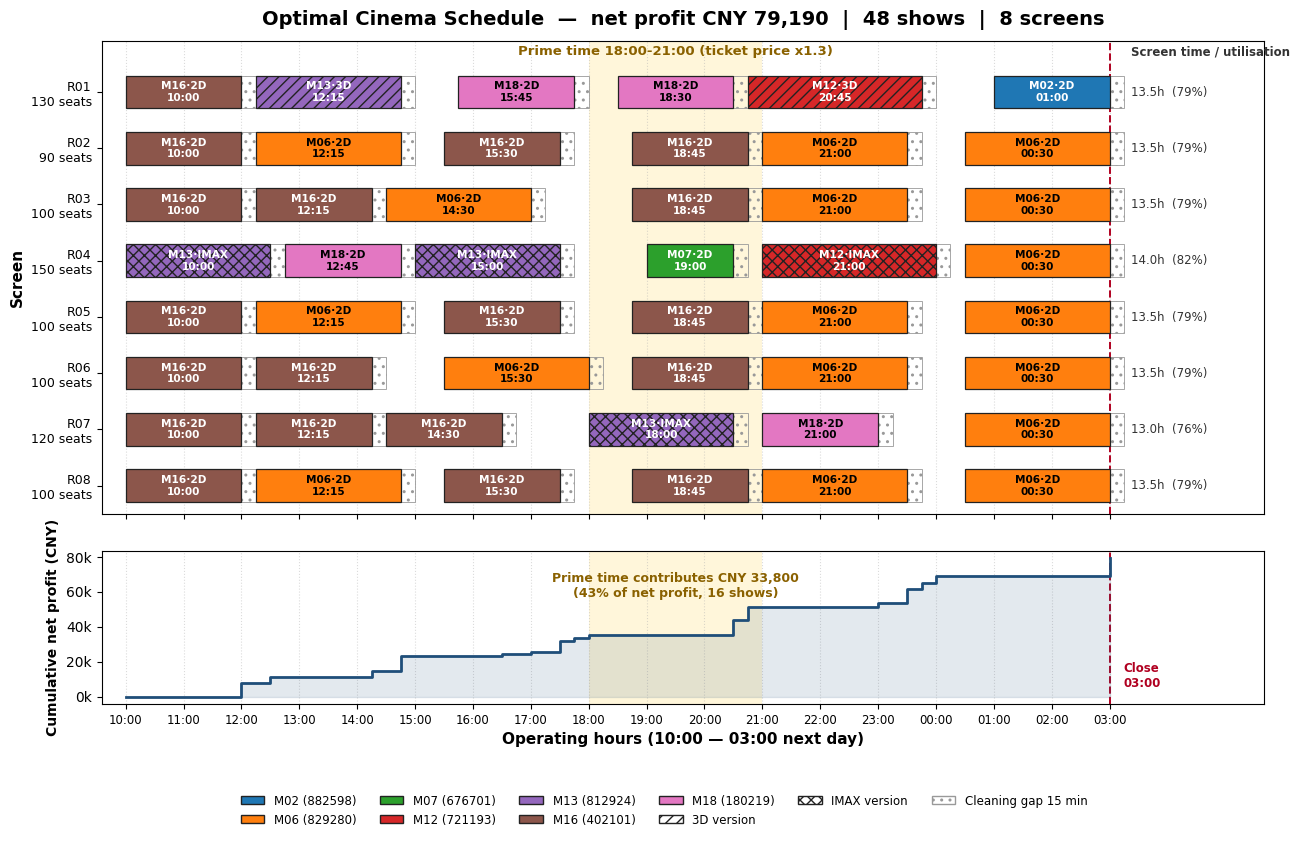

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams["axes.unicode_minus"] = False

PRIME_L, PRIME_R = min(prime_time), max(prime_time)

short_name = {m["id"]: f"M{i + 1:02d}" for i, m in enumerate(movie_data)}

used_movies = sorted({p["id"] for p in results}, key=lambda m: short_name[m])
palette = plt.get_cmap("tab20").colors
color_map = {m: palette[(2 * i) % 20] for i, m in enumerate(used_movies)}
hatch_map = {"2D": "", "3D": "///", "IMAX": "xxx"}
ypos = {r: i for i, r in enumerate(rooms)}

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(15, 8.6), sharex=True,
    gridspec_kw=dict(height_ratios=[3.1, 1], hspace=0.12))

for a in (ax, ax2):
    a.axvspan(PRIME_L, PRIME_R, color="#FFD24A", alpha=0.20, lw=0, zorder=0)
    a.axvline(CLOSE_MIN, color="#B00020", ls="--", lw=1.4, zorder=1)
    a.grid(axis="x", ls=":", alpha=0.45)
    a.set_axisbelow(True)
ax.text((PRIME_L + PRIME_R) / 2, -0.72,
        f"Prime time {minutes_to_time(PRIME_L)}-{minutes_to_time(PRIME_R)} "
        f"(ticket price x{prime_coeff})",
        ha="center", va="center", fontsize=9.5, color="#8A6100", fontweight="bold")

# ---------- Gantt bars ----------
for p in results:
    y, t, dur = ypos[p["room"]], p["start"], p["runtime"]
    c = color_map[p["id"]]
    ax.barh(y, dur, left=t, height=0.58, zorder=3, color=c,
            edgecolor="#222", linewidth=0.9, hatch=hatch_map[p["version"]])
    # 15-minute cleaning / turnaround block
    ax.barh(y, min_gap, left=t + dur, height=0.58, zorder=2,
            color="none", edgecolor="#999", linewidth=0.6, hatch="..")
    luminance = 0.299 * c[0] + 0.587 * c[1] + 0.114 * c[2]
    if dur >= 85:   # skip the label on narrow bars so text never overflows
        ax.text(t + dur / 2, y, f"{short_name[p['id']]}·{p['version']}\n{p['start_hhmm']}",
                ha="center", va="center", fontsize=7.6, zorder=4, fontweight="bold",
                color="black" if luminance > 0.5 else "white")

# ---------- Per-screen utilisation in the right margin ----------
for r in rooms:
    used = sum(p["runtime"] for p in results if p["room"] == r)
    ax.text(CLOSE_MIN + 22, ypos[r], f"{used / 60:.1f}h  ({used / CLOSE_MIN:.0%})",
            va="center", fontsize=8.5, color="#333")
ax.text(CLOSE_MIN + 22, -0.72, "Screen time / utilisation", fontsize=8.5,
        color="#333", fontweight="bold", va="center")

ax.set_yticks(range(len(rooms)))
ax.set_yticklabels([f"{r}\n{capacity[r]} seats" for r in rooms], fontsize=9)
ax.invert_yaxis()                       # R01 on top, matching the results table
ax.set_ylim(len(rooms) - 0.5, -0.9)
ax.set_ylabel("Screen", fontsize=11, fontweight="bold")
ax.set_title(f"Optimal Cinema Schedule  —  net profit CNY {model.objval:,.0f}  |  "
             f"{len(results)} shows  |  {len(rooms)} screens",
             fontsize=14, fontweight="bold", pad=12)

legend = [Patch(fc=color_map[m], ec="#222", label=f"{short_name[m]} ({m})")
          for m in used_movies]
legend += [Patch(fc="white", ec="#222", hatch=h, label=f"{v} version")
           for v, h in hatch_map.items() if h]
legend += [Patch(fc="none", ec="#999", hatch="..",
                 label=f"Cleaning gap {min_gap} min")]
fig.legend(handles=legend, ncol=6, fontsize=8.5, loc="lower center",
           bbox_to_anchor=(0.5, -0.045), frameon=False)

# ---------- Lower panel: cumulative net profit (accumulated at show end) ----------
cx, cy, running = [OPEN_MIN], [0], 0
for p in sorted(results, key=lambda d: d["end"]):
    running += p["net"]
    cx.append(p["end"])
    cy.append(running)
ax2.step(cx, cy, where="post", color="#1f4e79", lw=2, zorder=3)
ax2.fill_between(cx, cy, step="post", color="#1f4e79", alpha=0.12, zorder=2)

net_prime = sum(p["net"] for p in results if p["is_prime"])
ax2.annotate(f"Prime time contributes CNY {net_prime:,.0f}\n"
             f"({net_prime / running:.0%} of net profit, "
             f"{sum(p['is_prime'] for p in results)} shows)",
             xy=((PRIME_L + PRIME_R) / 2, running * 0.72), ha="center",
             fontsize=9, color="#8A6100", fontweight="bold")
ax2.set_ylabel("Cumulative net profit (CNY)", fontsize=10, fontweight="bold")
ax2.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:.0f}k")

# ---------- Shared wall-clock x axis ----------
ticks = list(range(OPEN_MIN, CLOSE_MIN + 1, 60))
ax2.set_xticks(ticks)
ax2.set_xticklabels([minutes_to_time(t) for t in ticks], fontsize=8.5)
ax2.set_xlim(OPEN_MIN - 25, CLOSE_MIN + 160)
ax2.set_xlabel("Operating hours (10:00 — 03:00 next day)",
               fontsize=11, fontweight="bold")
ax2.text(CLOSE_MIN + 14, running * 0.15, "Close\n03:00",
         color="#B00020", fontsize=8.5, va="center", ha="left", fontweight="bold")

plt.savefig("movie_schedule_gantt.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()